In [6]:
import shutil
import tensorflow as tf
from pathlib import Path
from tensorflow.keras import layers
from tensorflow.keras.layers import Flatten, Activation , Dense ,BatchNormalization ,Conv2D  ,MaxPooling2D,Rescaling
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.applications import ResNet50
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import numpy as np
from sklearn.utils.class_weight import compute_class_weight
import streamlit as st

In [8]:
import shutil
from pathlib import Path

original_dir = Path("dataset")  
new_base_dir = Path("waste_small")

def make_subset(subset_name, categories, split_ratio):  
    for category in categories:
        src = original_dir / category 
        dir = new_base_dir / subset_name / category
        dir.mkdir(parents=True, exist_ok=True)
        files=list(src.glob("*.jpg"))

        n=len(files)
        n_train=int(n*split_ratio["train"])
        n_val=int(n*split_ratio["validation"])
        if subset_name=="train":
            subset_files=files[:n_train]
        elif subset_name=="validation":
            subset_files=files[n_train:n_train+n_val]
        else:
            subset_files=files[n_train+n_val:]

        for f in subset_files:
            shutil.copy(f,dir / f.name)

categories= ["cardboard","glass","metal","paper","plastic","trash"]
split_ratio={"train":0.7,"validation":0.2,"test":0.1}

make_subset("train", categories, split_ratio)  
make_subset("validation", categories, split_ratio)   
make_subset("test", categories, split_ratio)




In [9]:
from tensorflow.keras.utils import image_dataset_from_directory
train_dataset = image_dataset_from_directory(
    new_base_dir / "train",
    image_size=(180, 180),
    batch_size=32)
validation_dataset = image_dataset_from_directory(
    new_base_dir / "validation",
    image_size=(180, 180),
    batch_size=32)
test_dataset = image_dataset_from_directory(
    new_base_dir / "test",
    image_size=(180, 180),
    batch_size=32)

Found 1766 files belonging to 6 classes.
Found 503 files belonging to 6 classes.
Found 258 files belonging to 6 classes.


In [10]:
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.shuffle(1000).prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_dataset.prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.prefetch(buffer_size=AUTOTUNE)

In [11]:
y_train = []
for _, labels in train_dataset:
    y_train.extend(labels.numpy())

y_train = np.array(y_train)
classes = np.unique(y_train)  # [0,1,2,3,4,5]
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weight_dict = dict(zip(classes, class_weights))
print(class_weight_dict)

{0: 1.0437352245862883, 1: 0.840952380952381, 2: 1.0255516840882695, 3: 0.7092369477911646, 4: 0.8733926805143423, 5: 3.0982456140350876}


=== Entraînement initial ===
Epoch 11/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 173s 3s/step - accuracy: 0.4916 - loss: 1.9959 - val_accuracy: 0.7376 - val_loss: 1.2242 - learning_rate: 0.0010
Epoch 12/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 150s 3s/step - accuracy: 0.7672 - loss: 1.0856 - val_accuracy: 0.8091 - val_loss: 1.0262 - learning_rate: 0.0010
Epoch 13/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 149s 3s/step - accuracy: 0.8099 - loss: 0.8996 - val_accuracy: 0.8191 - val_loss: 0.9801 - learning_rate: 0.0010
Epoch 14/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 148s 3s/step - accuracy: 0.8513 - loss: 0.8078 - val_accuracy: 0.8250 - val_loss: 0.9984 - learning_rate: 0.0010
Epoch 15/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 150s 3s/step - accuracy: 0.8418 - loss: 0.7758 - val_accuracy: 0.8449 - val_loss: 0.9090 - learning_rate: 0.0010
Epoch 16/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 150s 3s/step - accuracy: 0.8511 - loss: 0.7179 - val_accuracy: 0.8588 - val_loss: 0.8927 - learning_rate: 0.0010
Epoch 17/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 149s 3s/step - accur

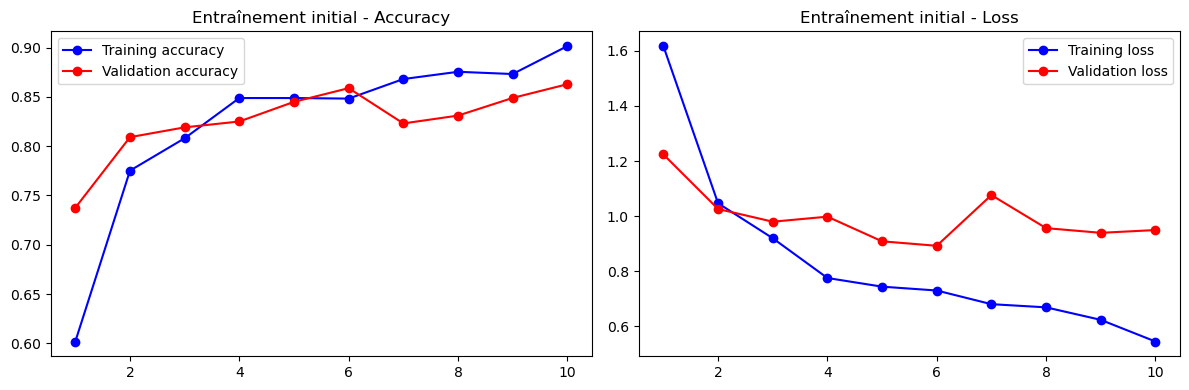

In [30]:
from tensorflow.keras import regularizers
conv_base = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(180, 180, 3)
)
conv_base.trainable = False

# Data augmentation
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2),
])

# Construction du modèle
inputs = tf.keras.Input(shape=(180, 180, 3))
x = data_augmentation(inputs)          
x = tf.keras.applications.resnet50.preprocess_input(x)   
x = conv_base(x)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation="relu",kernel_regularizer= regularizers.l2(0.001))(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(6, activation="softmax")(x)
model = tf.keras.Model(inputs, outputs)

model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=Adam(learning_rate=1e-3),
    metrics=["accuracy"]
)

# Entraînement initial
print("=== Entraînement initial ===")
history_initial = model.fit(
    train_dataset,
    epochs=20,   
    validation_data=validation_dataset,
    class_weight=class_weight_dict,
    initial_epoch=10,
    callbacks=[
        EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)
    ],
    verbose=1
)


# Évaluation sur le test set
print("=== Évaluation sur le test set ===")
test_loss, test_accuracy = model.evaluate(test_dataset)
print(f"Test accuracy: {test_accuracy:.4f}")
print(f"Test loss: {test_loss:.4f}")

# Visualisation
def plot_history(history, title):
    accuracy = history.history["accuracy"]
    val_accuracy = history.history["val_accuracy"]
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]
    epochs = range(1, len(accuracy) + 1)
    
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.plot(epochs, accuracy, "bo-", label="Training accuracy")
    plt.plot(epochs, val_accuracy, "ro-", label="Validation accuracy")
    plt.title(f"{title} - Accuracy")
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, "bo-", label="Training loss")
    plt.plot(epochs, val_loss, "ro-", label="Validation loss")
    plt.title(f"{title} - Loss")
    plt.legend()
    
    plt.tight_layout()
    plt.show()

plot_history(history_initial, "Entraînement initial")


In [26]:
model.save("waste_classifier.keras")